In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('Planets_dataset.csv', header=27)

In [3]:
def log_errs(val, errs, err_lower=None):
    err_lower = errs if err_lower is None else np.abs(err_lower)
    upper = np.log10(val+errs)
    mask = (val - errs <= 0)
    lower = np.log10(val-err_lower)
    lower[mask] = -np.inf
    logerr = 0.5*(upper-lower)
    return logerr

In [4]:
x = np.log10(df['pl_rade'].values)
y = np.log10(df['pl_masse'].values)
xerr = log_errs(df['pl_rade'].values, df['pl_radeerr1'].values, df['pl_radeerr2'].values)
yerr = log_errs(df['pl_masse'].values, df['pl_masseerr1'].values, df['pl_masseerr2'].values)

xmask = ~np.isinf(xerr)
ymask = ~(np.isinf(yerr) | np.isnan(yerr))
mask = xmask & ymask

/tmp/ipykernel_36255/2343081272.py:5: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-err_lower)
/tmp/ipykernel_36255/2343081272.py:5: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-err_lower)


<ErrorbarContainer object of 3 artists>

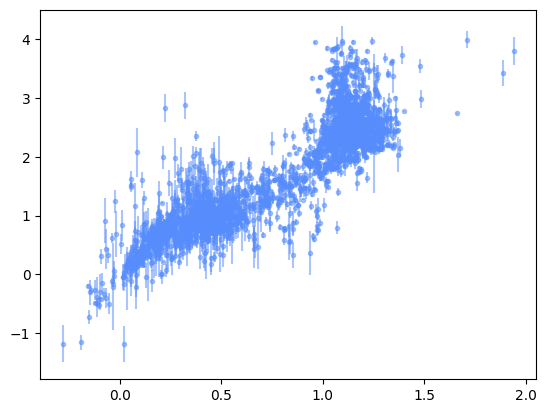

In [5]:
plt.errorbar(x[mask], y[mask], yerr=yerr[mask], fmt='o', alpha=0.5, ms=3)

In [6]:
N = int(np.sum(ymask))
X = x[ymask].reshape(-1,1)
y = y[ymask].reshape(-1,1)
yerr = yerr[ymask].reshape(-1,1)

In [7]:
def kernel(a, b, l=1, sigm_f=2):
    sqdist = np.sum(a**2,1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
    return sigm_f**2 * np.exp(-.5 * (1/l**2) * sqdist)

In [10]:
#Cholesky decomposition is used instead of directly inverting the the matrix
K = kernel(X, X)
L = np.linalg.cholesky(K + yerr.flatten()*np.eye(N))

In [11]:
# points we're going to make predictions at.
n=50
Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)

In [12]:
# mean at our test points.
Lk = np.linalg.solve(L, kernel(X, Xtest))
mu = np.dot(Lk.T, np.linalg.solve(L, y))

In [13]:
# variance at our test points.
K_ = kernel(Xtest, Xtest)
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
s = np.sqrt(s2)

In [14]:
#draw samples from the prior distribution
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n))
f_prior = np.dot(L, np.random.normal(size=(n,5)))

In [15]:
#draw samples from the posterior distribution
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,5)))

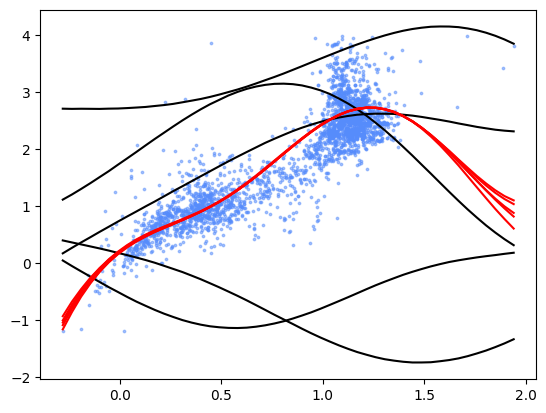

In [16]:
plt.scatter(X, y, alpha=0.5, s=3)
plt.plot(Xtest, f_prior, 'k-', label='prior')
plt.plot(Xtest, f_post, 'r-', label='posterior')

In [17]:
def posterior(X, y, yerr, l=1, sigm_f=1):
    loc_kernel = lambda a, b: kernel(a, b, l, sigm_f)

    #Cholesky decomposition is used instead of directly inverting the the matrix
    K = loc_kernel(X, X)
    L = np.linalg.cholesky(K + yerr.flatten()*np.eye(N))

    # points we're going to make predictions at.
    n=50
    Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)

    # mean at our test points.
    Lk = np.linalg.solve(L, loc_kernel(X, Xtest))
    mu = np.dot(Lk.T, np.linalg.solve(L, y))

    # variance at our test points.
    K_ = loc_kernel(Xtest, Xtest)
    s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
    s = np.sqrt(s2)

    #draw samples from the posterior distribution
    L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
    f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,5)))
    return f_post

In [31]:
def posterior_3k(X, y, yerr, l=[100,200,300], sigm_f=[1,2,3]):
    loc_kernel = lambda a, b: kernel(a, b, l[0], sigm_f[0]) + kernel(a, b, l[1], sigm_f[1]) + kernel(a, b, l[2], sigm_f[2])

    #Cholesky decomposition is used instead of directly inverting the the matrix
    K = loc_kernel(X, X)
    L = np.linalg.cholesky(K + yerr.flatten()*np.eye(N))

    # points we're going to make predictions at.
    n=50
    Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)

    # mean at our test points.
    Lk = np.linalg.solve(L, loc_kernel(X, Xtest))
    mu = np.dot(Lk.T, np.linalg.solve(L, y))

    # variance at our test points.
    K_ = loc_kernel(Xtest, Xtest)
    s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
    s = np.sqrt(s2)

    #draw samples from the posterior distribution
    L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
    f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,5)))
    return f_post

In [ ]:
f_post_3k = posterior_3k(X, y, yerr, l=[100,200,300], sigm_f=[1,2,3])
f_post = posterior(X, y, yerr, l=0.1, sigm_f=1)

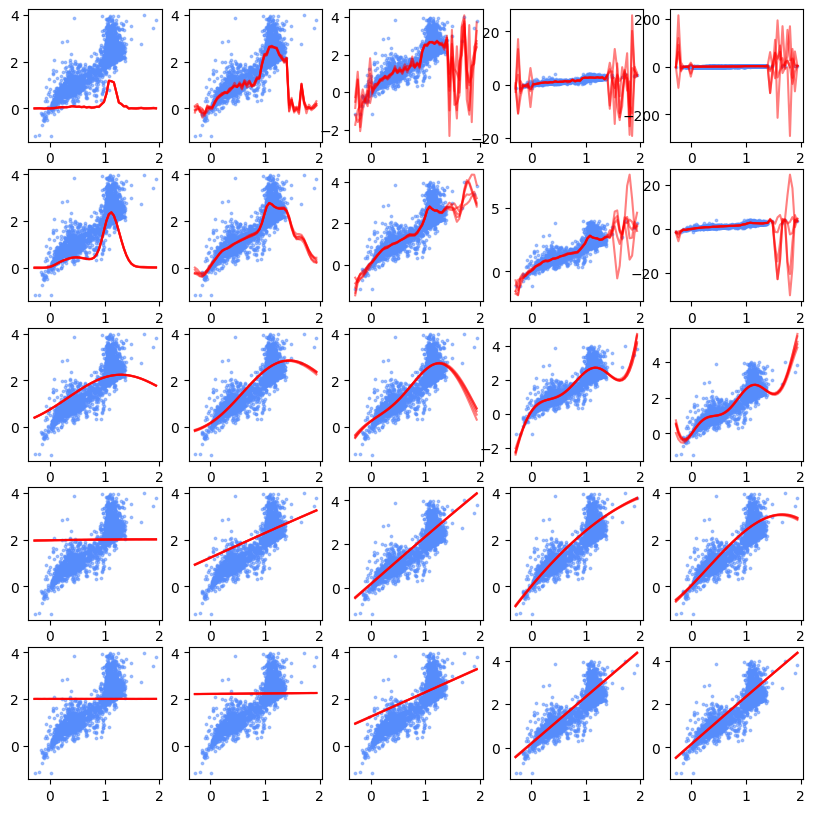

In [43]:
l = np.geomspace(0.01, 100, 5)
sigm_f = np.geomspace(0.01, 100, 5)

fg, ax = plt.subplots(len(l), len(sigm_f), figsize=(10,10))

for i, l_ in enumerate(l):
    for j, sigm_f_ in enumerate(sigm_f):
        f_post = posterior(X, y, yerr, l=l_, sigm_f=sigm_f_)
        ax[i,j].scatter(X, y, alpha=0.5, s=3)
        ax[i,j].plot(Xtest, f_post, 'r-', alpha=0.5)

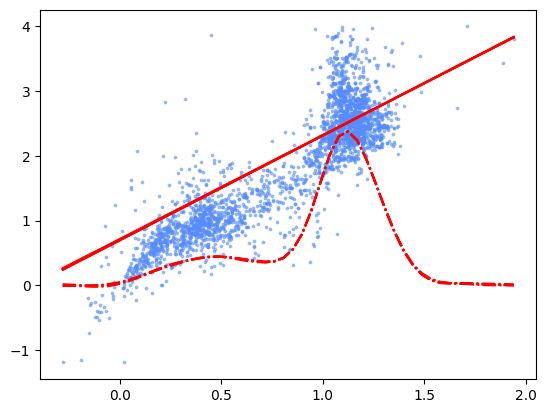

In [41]:
plt.scatter(X, y, alpha=0.5, s=3)
plt.plot(Xtest, f_post_3k, 'r-', label='posterior')
plt.plot(Xtest, f_post, 'r-.', label='posterior')

In [9]:
class our_kernel_fit():
    def __init__(self, X, y, sigm_f=1, l=1, n_samples=50, n_runs=5):
        self.X = X
        self.y = y
        self.sigm_f = sigm_f
        self.l = l
        self.n_samples = n_samples
        self.n_runs = n_runs

        self.set_kernel = lambda a, b: self.kernel(a, b, l, sigm_f)

        self.K = self.kernel(X, X, l, sigm_f) #N*N
        self.L = np.linalg.cholesky(self.K + 1e-6*np.eye(len(X))) #N*N

        self.Xtest = np.linspace(X.min(), X.max(), n_samples).reshape(-1,1) #n_samples*1

        self.Lk = np.linalg.solve(self.L, self.kernel(X, self.Xtest, l, sigm_f))
        self.mu = np.dot(self.Lk.T, np.linalg.solve(self.L, y))
        self.K_ = self.kernel(self.Xtest, self.Xtest, l, sigm_f)
        self.s2 = np.diag(self.K_) - np.sum(self.Lk**2, axis=0)
        self.s = np.sqrt(self.s2)

        self.L_post = np.linalg.cholesky(self.K_ + 1e-6*np.eye(n_samples) - np.dot(self.Lk.T, self.Lk))
        self.f_post = self.mu.reshape(-1,1) + np.dot(self.L, np.random.normal(size=(n_samples,n_runs)))

    def kernel(self, a, b, l=1, sigm_f=1):
        sqdist = np.sum(a**2,1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
        return sigm_f**2 * np.exp(-.5 * (1/l**2) * sqdist)

    def predict(self, Xtest=None):
        if Xtest is None:
            return self.f_post
        self.Xtest = Xtest
        self.Lk = np.linalg.solve(self.L, self.kernel(X, Xtest, self.l, self.sigm_f))
        self.mu = np.dot(self.Lk.T, np.linalg.solve(self.L, y))
        self.K_ = self.kernel(Xtest, Xtest, self.l, self.sigm_f)
        self.s2 = np.diag(self.K_) - np.sum(self.Lk**2, axis=0)
        self.s = np.sqrt(self.s2)

        self.L_post = np.linalg.cholesky(self.K_ + 1e-6*np.eye(self.n_samples) - np.dot(self.Lk.T, self.Lk))
        self.f_post = self.mu.reshape(-1,1) + np.dot(self.L, np.random.normal(size=(self.n_samples,self.n_runs)))
        return self.f_post


In [10]:
one_kern = our_kernel_fit(X, y)

ValueError: shapes (2920,2920) and (50,5) not aligned: 2920 (dim 1) != 50 (dim 0)